# 11 — Prompt Geometry Core Experiments

**Status: current — this is the primary analysis notebook.** Reads
`evaluate_prompt_decomposition` outputs for Qwen MATH-500 Best-of-8
(`math500_prompt_decomposition_{results.json,oof.csv}`), rerun 2026-07-18 after
the truncation-bias fix.

Covers the **within-prompt regime**: given a fixed problem, does geometry
predict which of the N=8 sampled traces is correct? All contrasts are
prompt-grouped 5-fold OOF with 1,000-draw prompt-cluster bootstrap.

**Headline findings recorded here:**

- **Localization replicates at every layer.** Restricting RMD to the
  highest-entropy 20% of tokens beats full-trace RMD by +0.052/+0.055/+0.058
  centered AUC at L7/14/21 (all p ≤ 0.006), and the effect grows with depth.
- **It is entropy-specific, not a token-count artifact.** A matched random-20%
  control tracks full-trace RMD; `rmd_he_q20 − rmd_random_q20` is
  +0.049/+0.058/+0.057 (p ≤ 0.014).
- **But it only ties the free output baselines.** `rmd_he_q20 − logprob` at L21
  is −0.004 centered (p=0.926), and geometry is *below* logprob at L7/L14.
- **Not entropy in disguise, though.** Label-free residualization on
  entropy+logprob+length keeps nearly all discrimination at L21 (0.645 residual
  vs 0.654 raw) — geometry is linearly complementary; the flat incremental probe
  reflects saturation on 117 mixed prompts, not redundancy.
- **Selection is negative with a structural ceiling** (sections 8–9): all 15
  tie-break variants within ±0.006 of majority vote, 15/15 paired p ≥ 0.248,
  because only ~10 of 500 prompts have a tie with correctness headroom.

The complementary **between-prompt regime** — where geometry actually wins — is
in `12_wave1_abstention`.

Inference caveats that apply to everything below: 21 contrasts x 3 layers x 2
metrics, unadjusted (the single significant incremental-probe cell, p=0.024,
would not survive correction); bootstrap CIs do not propagate reference
refitting; parseable-only conditioning is on an outcome-correlated event
(correct traces parse at 1.000 vs 0.815 for incorrect).

## 0. Setup and artifact paths

Loads three artifacts produced by `evaluate_prompt_decomposition`:

| Artifact | Contents |
|:---|:---|
| `..._prompt_decomposition_results.json` | Per-layer method scores, prespecified paired contrasts with bootstrap CIs, alignment diagnostics, truncation audit |
| `..._prompt_decomposition_oof.csv` | 12,000 rows (3 layers x 4,000 traces), 34 columns — one out-of-fold score per method per trace, plus answer/entropy/length metadata |
| `..._prompt_selection_results.json` | Best-of-8 selector Pass@1 and paired tie-breaker deltas (retired stage; kept for sections 8–9) |

**Leakage protocol.** Everything is 5-fold **prompt-grouped** cross-fitting: all
8 samples of a problem live in the same fold, and PCA, the correct-trace
Mahalanobis reference, the RMD background, the contrastive directions, and the
supervised probes are all fit on training prompts only. A trace's score is
always produced by a model that never saw its prompt. Uncertainty is a
1,000-draw **prompt-cluster bootstrap** resampling problems, not traces, so the
intervals respect the clustering of 8 correlated samples per problem.

Change only the configuration cell to point at another compatible run — the
DeepSeek and DeepSeek-Llama cells use the same schema. Missing artifacts are
reported without stopping later cells.

In [34]:
from __future__ import annotations

import csv
import json
import math
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display


def find_repo_root(start: Path | None = None) -> Path:
    candidate = (start or Path.cwd()).resolve()
    for path in (candidate, *candidate.parents):
        if (path / ".git").exists():
            return path
    raise FileNotFoundError("Could not find the repository root")


ROOT = find_repo_root()
MODEL = "qwen"
DATASET = "math500"
RUN_DIR = ROOT / "results" / "qwen_bestofn_full" / DATASET

DECOMPOSITION_PATH = RUN_DIR / f"{DATASET}_prompt_decomposition_results.json"
OOF_PATH = RUN_DIR / f"{DATASET}_prompt_decomposition_oof.csv"
SELECTION_PATH = RUN_DIR / f"{DATASET}_prompt_selection_results.json"

FOCUS_LAYER = 14
FOCUS_METHODS = [
    "logprob",
    "rmd_high_entropy_q20",
    "contrast_high_entropy_q20",
    "probe_outputs_plus_contrast_high_entropy_q20",
]

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
})

RUN_DIR

PosixPath('/home/djaniak/projects/reasoning-geometry-probe/results/qwen_bestofn_full/math500')

In [35]:
INTEGER_FIELDS = {
    "prompt_id", "trace_id", "sample_id", "is_correct", "fold", "layer", "trace_length"
}


def load_json_if_present(path: Path) -> dict:
    if not path.exists():
        return {}
    with path.open(encoding="utf-8") as handle:
        return json.load(handle)


def load_csv_if_present(path: Path) -> list[dict]:
    if not path.exists():
        return []
    rows = []
    with path.open(newline="", encoding="utf-8") as handle:
        for raw in csv.DictReader(handle):
            row = dict(raw)
            for key, value in list(row.items()):
                if value == "":
                    row[key] = None
                elif key in INTEGER_FIELDS:
                    row[key] = int(value)
                elif key in {"mean_logprob"} or key.endswith("_score"):
                    row[key] = float(value)
            rows.append(row)
    return rows


def show_rows(rows: list[dict], columns: list[str] | None = None, limit: int = 20) -> None:
    if not rows:
        display(Markdown("_No rows available for this view._"))
        return
    columns = columns or list(rows[0])
    shown = rows[:limit]

    def cell(value):
        if value is None:
            return "NA"
        if isinstance(value, float):
            return f"{value:.4f}" if math.isfinite(value) else "NA"
        return str(value).replace("|", "\\|")

    lines = [
        "| " + " | ".join(columns) + " |",
        "|" + "|".join("---" for _ in columns) + "|",
    ]
    lines.extend(
        "| " + " | ".join(cell(row.get(column)) for column in columns) + " |"
        for row in shown
    )
    if len(rows) > limit:
        lines.append(f"\n_Showing {limit} of {len(rows)} rows._")
    display(Markdown("\n".join(lines)))


def note(ax, message: str) -> None:
    ax.axis("off")
    ax.text(0.5, 0.5, message, ha="center", va="center", wrap=True)


def ci_error(point, low, high):
    if any(value is None or not math.isfinite(float(value)) for value in (point, low, high)):
        return None
    return [[float(point) - float(low)], [float(high) - float(point)]]


decomposition = load_json_if_present(DECOMPOSITION_PATH)
selection = load_json_if_present(SELECTION_PATH)
oof_rows = load_csv_if_present(OOF_PATH)

artifact_rows = [
    {"artifact": path.name, "present": path.exists(), "path": str(path)}
    for path in (DECOMPOSITION_PATH, OOF_PATH, SELECTION_PATH)
]
show_rows(artifact_rows)

if not decomposition or not oof_rows:
    display(Markdown(
        "**Generate missing/stale artifacts from the repository root:**\n\n"
        "```bash\n"
        "CUDA_VISIBLE_DEVICES=\"\" uv run dvc repro --single-item evaluate_prompt_decomposition@0\n"
        "CUDA_VISIBLE_DEVICES=\"\" uv run dvc repro --single-item evaluate_prompt_selection@0\n"
        "```"
    ))

| artifact | present | path |
|---|---|---|
| math500_prompt_decomposition_results.json | True | /home/djaniak/projects/reasoning-geometry-probe/results/qwen_bestofn_full/math500/math500_prompt_decomposition_results.json |
| math500_prompt_decomposition_oof.csv | True | /home/djaniak/projects/reasoning-geometry-probe/results/qwen_bestofn_full/math500/math500_prompt_decomposition_oof.csv |
| math500_prompt_selection_results.json | True | /home/djaniak/projects/reasoning-geometry-probe/results/qwen_bestofn_full/math500/math500_prompt_selection_results.json |

## 1. Data, parseability, and OOF audit

**Why this comes first.** The outcome label is "the `\\boxed{}` answer parses
and matches gold". A trace that runs into the 1,024-token cap never emits a
`\\boxed{}`, so it is *automatically* labelled incorrect. If censoring is
heavy, a geometry score that merely detects "this trace rambled and got cut off"
will look like a correctness detector. This section quantifies that exposure
before any geometry is interpreted.

**What the Qwen run shows:**

- **Data complete.** 500/500 prompts with all 8 samples, `partial_data=false`,
  no duplicate trace IDs, no excluded prompts.
- **Censoring is real but bounded.** 8.2% of traces are unparsed (328/4,000),
  8.45% hit the token cap, and **unparsed traces are 18.5% of the entire
  incorrect class**. Parse rate is 1.000 for correct traces vs 0.815 for
  incorrect ones.
- **So all-trace pooled AUCs are not trustworthy**, and this notebook reports
  **parseable-only** numbers throughout (3,672 traces). Trace length alone pools
  at AUC 0.737 on all traces but collapses to 0.478 — chance — within-prompt on
  parseable traces. That gap *is* the confound, measured.

**The cost of the fix.** Conditioning on parseability conditions on an
outcome-correlated event, which is its own (smaller) bias, and it shrinks the
within-prompt population hard: of 500 prompts only **117 are "mixed"** (contain
both a parseable correct and a parseable incorrect trace), giving **1,104
within-prompt pairs**. Every within-prompt number below rests on those 117
prompts. That is the binding power constraint in this notebook, and section 8's
selection null is a direct consequence of it.

| layer | all_traces | parseable_traces | mixed_parseable_prompts | unparsed_rate | capped_rate |
|---|---|---|---|---|---|
| 7 | 4000 | 3672 | 117 | 0.0820 | 0.0845 |
| 14 | 4000 | 3672 | 117 | 0.0820 | 0.0845 |
| 21 | 4000 | 3672 | 117 | 0.0820 | 0.0845 |

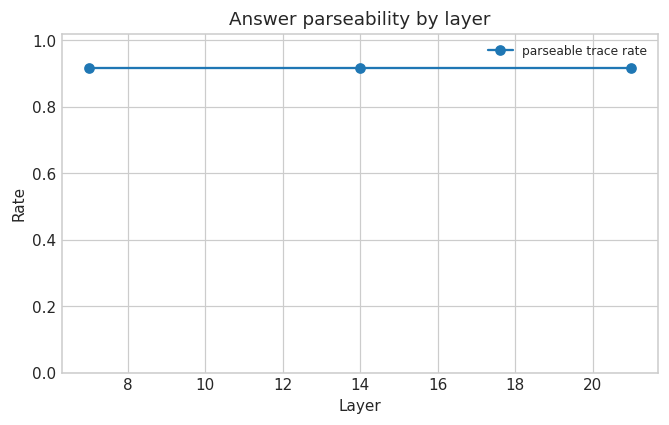

In [36]:
audit_rows = []
if decomposition:
    for layer, payload in sorted(decomposition.get("layers", {}).items(), key=lambda item: int(item[0])):
        parseable = payload.get("parseable_only", {})
        method = parseable.get("methods", {}).get("rmd", {})
        truncation = payload.get("truncation", {})
        audit_rows.append({
            "layer": int(layer),
            "all_traces": truncation.get("n_traces"),
            "parseable_traces": parseable.get("n_parseable_traces"),
            "mixed_parseable_prompts": method.get("n_mixed_prompts"),
            "unparsed_rate": truncation.get("unparsed_rate"),
            "capped_rate": truncation.get("capped_rate"),
        })
elif selection:
    for layer, payload in sorted(selection.get("layers", {}).items(), key=lambda item: int(item[0])):
        parsing = payload.get("answer_parsing", {})
        audit_rows.append({
            "layer": int(layer),
            "all_traces": parsing.get("n_traces"),
            "parseable_traces": parsing.get("n_parsed"),
            "mixed_parseable_prompts": None,
            "unparsed_rate": 1.0 - parsing["parse_rate"] if parsing.get("parse_rate") is not None else None,
            "capped_rate": None,
        })

show_rows(audit_rows)

fig, ax = plt.subplots(figsize=(7, 4))
if audit_rows:
    layers = [row["layer"] for row in audit_rows]
    parse_rates = [
        row["parseable_traces"] / row["all_traces"]
        if row.get("parseable_traces") is not None and row.get("all_traces")
        else np.nan
        for row in audit_rows
    ]
    ax.plot(layers, parse_rates, marker="o", label="parseable trace rate")
    ax.set(ylim=(0, 1.02), xlabel="Layer", ylabel="Rate", title="Answer parseability by layer")
    ax.legend()
else:
    note(ax, "No decomposition or selection artifact found")
plt.show()

## 2. Readout × region factorial

**The central identification plot.** Two factors crossed:

- **Region** — which tokens the score aggregates over: `full` (all tokens),
  `high_entropy_q20` (the 20% of tokens with highest predictive entropy),
  `tail_q20` (the final 20%), `random_q20` (a seeded random 20%, the matched
  control for "does using fewer tokens help by itself?").
- **Readout** — how the region is turned into a scalar: `rmd` (unsupervised
  relative Mahalanobis distance) vs `contrast` (supervised projection onto a
  cross-prompt correct-minus-incorrect direction).

Holding one factor fixed and varying the other separates "where in the trace the
signal lives" from "how much supervision it takes to read it out".

**Two metrics, both reported.** `within_prompt_macro` averages pairwise
concordance within each prompt and then across prompts (equal weight per
problem); `prompt_centered_auc` subtracts each prompt's mean score first and
pools. They answer the same question differently; agreement between them is
reassurance, disagreement is a flag.

**Result (parseable, 117 mixed prompts, within-macro / centered):**

| Method | L7 | L14 | L21 |
|:--|:--|:--|:--|
| rmd | 0.503 / 0.513 | 0.515 / 0.503 | 0.574 / 0.547 |
| rmd_high_entropy_q20 | 0.588 / 0.564 | 0.588 / 0.557 | **0.654 / 0.605** |
| contrast_high_entropy_q20 | 0.617 / 0.574 | 0.640 / 0.590 | 0.660 / 0.617 |
| probe_outputs + rmd_he_q20 | 0.662 / 0.600 | 0.629 / 0.590 | 0.683 / 0.609 |

Free output baselines, for scale (layer-invariant): entropy 0.660 / 0.611,
logprob 0.649 / 0.609, cross-fitted output probe 0.634 / 0.592.

**Read the table two ways.** Down a column: full-trace RMD is barely above
chance within-prompt (0.503–0.574) and localizing to high-entropy tokens is what
rescues it. Across columns: the localized effect *grows with depth*, peaking at
L21. But against the baseline row: even the best geometry cell only reaches the
free entropy/logprob baselines — it never clears them.

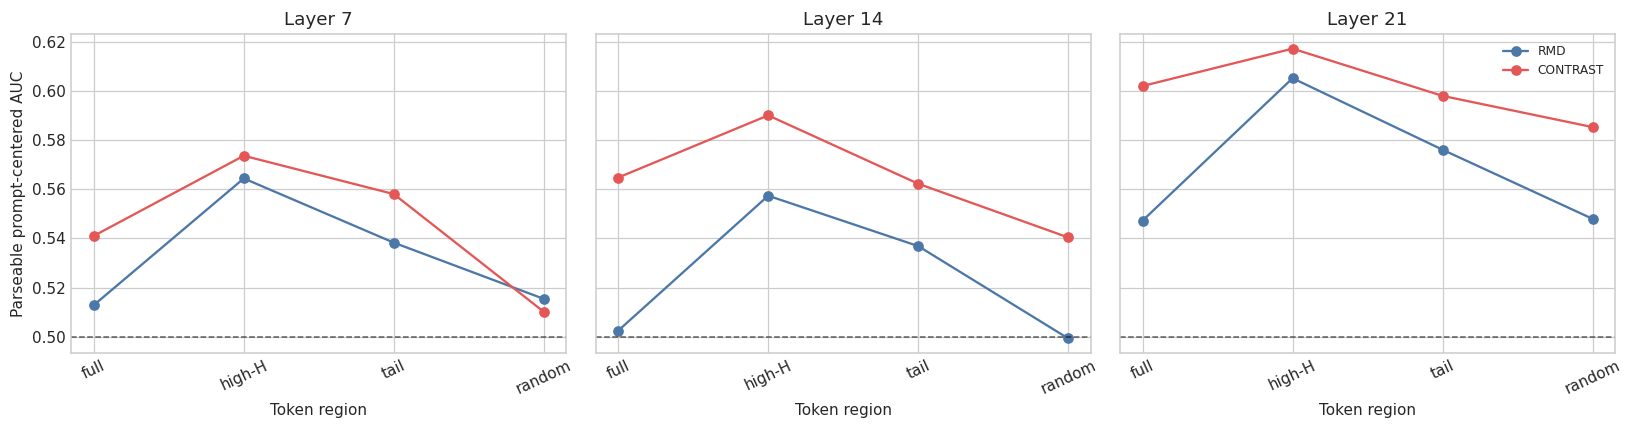

In [46]:
REGION_ORDER = ["full", "high_entropy_q20", "tail_q20", "random_q20"]
READOUT_COLORS = {"rmd": "#4C78A8", "contrast": "#E45756"}


def method_design(method: str):
    if method == "rmd":
        return "rmd", "full"
    if method.startswith("rmd_") and method.removeprefix("rmd_") in REGION_ORDER:
        return "rmd", method.removeprefix("rmd_")
    if method.startswith("contrast_") and method.removeprefix("contrast_") in REGION_ORDER:
        return "contrast", method.removeprefix("contrast_")
    return None


factorial_rows = []
for layer, payload in decomposition.get("layers", {}).items():
    methods = payload.get("parseable_only", {}).get("methods", {})
    for method, metrics in methods.items():
        design = method_design(method)
        if design:
            readout, region = design
            factorial_rows.append({
                "layer": int(layer),
                "method": method,
                "readout": readout,
                "region": region,
                "centered_auc": metrics.get("prompt_centered_auc"),
                "within_macro": metrics.get("within_prompt_macro"),
                "n_mixed_prompts": metrics.get("n_mixed_prompts"),
            })

# show_rows(factorial_rows, ["layer", "readout", "region", "centered_auc", "within_macro", "n_mixed_prompts"])

layer_values = sorted({row["layer"] for row in factorial_rows})
fig, axes = plt.subplots(1, max(1, len(layer_values)), figsize=(5 * max(1, len(layer_values)), 4), sharey=True)
axes = np.atleast_1d(axes)
if not factorial_rows:
    note(axes[0], "Run the decomposition DVC stage to populate the factorial")
else:
    for ax, layer in zip(axes, layer_values):
        subset = [row for row in factorial_rows if row["layer"] == layer]
        for readout in ("rmd", "contrast"):
            values = {
                row["region"]: row["centered_auc"]
                for row in subset
                if row["readout"] == readout
            }
            x = [index for index, region in enumerate(REGION_ORDER) if values.get(region) is not None]
            y = [values[REGION_ORDER[index]] for index in x]
            if x:
                ax.plot(x, y, marker="o", label=readout.upper(), color=READOUT_COLORS[readout])
        ax.axhline(0.5, color="black", lw=1, ls="--", alpha=0.6)
        ax.set_xticks(range(len(REGION_ORDER)), ["full", "high-H", "tail", "random"], rotation=25)
        ax.set(title=f"Layer {layer}", xlabel="Token region")
    axes[0].set_ylabel("Parseable prompt-centered AUC")
    axes[-1].legend()
plt.tight_layout()
plt.show()

## 3. Entropy specificity: high-entropy vs matched random 20%

**The control that makes section 2 mean something.** `rmd_high_entropy_q20`
beats `rmd` — but it also uses only a fifth of the tokens. Maybe averaging over
fewer, less-redundant tokens is simply a better estimator, and entropy has
nothing to do with it. `rmd_random_q20` tests exactly that: same token budget,
same aggregation, positions drawn at random with a fixed seed.

If the gain were about token count, high-entropy and random would move together.
They do not.

**Result:** `rmd_high_entropy_q20 − rmd_random_q20` = **+0.049 / +0.058 /
+0.057** centered AUC at L7/L14/L21, all p ≤ 0.014. The random control instead
tracks full-trace RMD almost exactly. So the localization is **entropy-specific**:
it matters *which* tokens, not *how many*.

The contrastive version of the same test is weaker and mixed at L21 (centered
p=0.128, macro p=0.032) — supervision does not sharpen the localization.

Both metrics are shown with raw prompt-bootstrap intervals. These are
unadjusted; see the multiplicity note in the header.

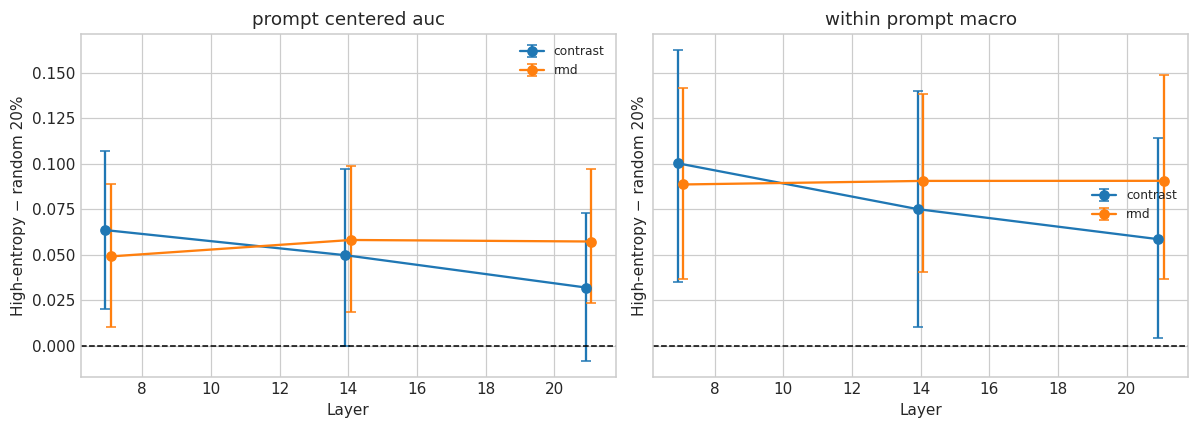

In [47]:
def flatten_score_deltas(result: dict) -> list[dict]:
    rows = []
    for layer, payload in result.get("layers", {}).items():
        parseable = payload.get("parseable_only", {})
        comparisons = parseable.get("paired_score_deltas", parseable.get("paired_contrastive_deltas", {}))
        for comparison, metrics in comparisons.items():
            for metric, values in metrics.items():
                rows.append({
                    "layer": int(layer),
                    "comparison": comparison,
                    "metric": metric,
                    "point": values.get("point_estimate"),
                    "ci_low": values.get("ci_low"),
                    "ci_high": values.get("ci_high"),
                    "p": values.get("p_two_sided"),
                    "n_valid": values.get("n_valid"),
                })
    return rows


paired_rows = flatten_score_deltas(decomposition)
specificity_names = {
    "rmd_high_entropy_q20_minus_rmd_random_q20",
    "contrast_high_entropy_q20_minus_contrast_random_q20",
}
specificity_rows = [row for row in paired_rows if row["comparison"] in specificity_names]
# show_rows(specificity_rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, metric in zip(axes, ("prompt_centered_auc", "within_prompt_macro")):
    subset = [row for row in specificity_rows if row["metric"] == metric]
    if not subset:
        note(ax, "Random-control results not available")
        continue
    for offset, comparison in zip((-0.08, 0.08), sorted(specificity_names)):
        rows = sorted([row for row in subset if row["comparison"] == comparison], key=lambda row: row["layer"])
        if not rows:
            continue
        x = np.asarray([row["layer"] for row in rows], dtype=float) + offset
        y = np.asarray([row["point"] for row in rows], dtype=float)
        low = np.asarray([row["ci_low"] for row in rows], dtype=float)
        high = np.asarray([row["ci_high"] for row in rows], dtype=float)
        ax.errorbar(x, y, yerr=np.vstack([y - low, high - y]), marker="o", capsize=3, label=comparison.split("_high_")[0])
    ax.axhline(0, color="black", lw=1, ls="--")
    ax.set(title=metric.replace("_", " "), xlabel="Layer", ylabel="High-entropy − random 20%")
    ax.legend()
plt.tight_layout()
plt.show()

## 4. Cross-prompt direction alignment

**A different question from the AUC sections.** Not "does geometry predict
correctness" but "**is there a shared direction?**" — i.e. does the
correct-minus-incorrect displacement point the same way across *different
problems*? If yes, there is a single "wrongness" axis in hidden space; if no,
each problem deviates in its own idiosyncratic direction and geometry is
prompt-local.

**Construction.** Each training prompt contributes one normalized
correct-minus-incorrect direction. The **resultant length** of those unit
vectors measures how aligned they are (1.0 = perfectly parallel; ~1/sqrt(n) =
random). The observed resultant is compared against a within-prompt
**label-shuffled null** (1,000 shuffles), which fixes the geometry and destroys
only the correct/incorrect assignment. Reported per fold — a pooled effect
carried by one fold would be fragile.

**Result: real, consistent across folds, and small.** At L21,
`high_entropy_q20` observed alignment is 0.164–0.200 across the 5 folds against
a null of ~0.100–0.105, p ≤ 0.004 in every fold. It replicates; it is not a
one-fold artifact.

But note the scale: **mean pairwise cosine is only 0.016–0.029.** The shared
component is statistically detectable and geometrically tiny. Prompts mostly
deviate in their own directions.

**And at L21 the alignment is not region-specific.** The `random_q20` control
*also* clears its null there (0.148–0.186 vs ~0.101–0.105, p ≤ 0.005), whereas
at L7 and L14 it does not (p up to 0.25 and 0.21). So the depth-21
representation has a globally shared correct-vs-incorrect component that any
token subset picks up — the entropy localization of sections 2–3 is *not* what
drives the alignment result. Two separate phenomena, easily conflated.

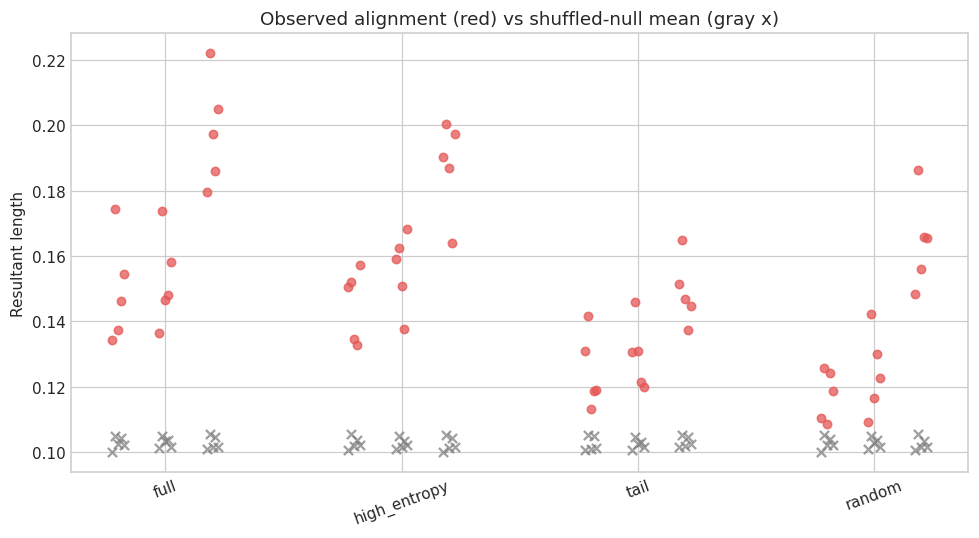

In [48]:
alignment_rows = []
for item in decomposition.get("contrastive", {}).get("alignment_diagnostics", []):
    null = item.get("null", {})
    alignment_rows.append({
        "fold": item.get("fold"),
        "layer": item.get("layer"),
        "region": item.get("region"),
        "n_prompt_vectors": item.get("n_prompt_vectors"),
        "observed": item.get("observed_alignment"),
        "pairwise_cosine": item.get("observed_pairwise_cosine"),
        "null_mean": null.get("mean"),
        "null_low": null.get("ci_low"),
        "null_high": null.get("ci_high"),
        "p": null.get("p_value"),
    })

# show_rows(alignment_rows, limit=30)

fig, ax = plt.subplots(figsize=(9, 5))
if not alignment_rows:
    note(ax, "Alignment diagnostics not available")
else:
    regions = [region for region in REGION_ORDER if any(row["region"] == region for row in alignment_rows)]
    positions = {region: index for index, region in enumerate(regions)}
    for row in alignment_rows:
        x = positions[row["region"]] + (int(row["layer"]) - 14) / 35 + (int(row.get("fold") or 0) - 2) / 80
        ax.scatter(x, row["observed"], color=READOUT_COLORS["contrast"], alpha=0.75, s=30)
        if row.get("null_mean") is not None:
            ax.scatter(x, row["null_mean"], color="gray", marker="x", alpha=0.75)
    ax.set_xticks(range(len(regions)), [region.replace("_q20", "") for region in regions], rotation=20)
    ax.set(ylabel="Resultant length", title="Observed alignment (red) vs shuffled-null mean (gray x)")
plt.tight_layout()
plt.show()

## 5. Prespecified paired identification tests

**The confirmatory section.** Every contrast here was specified before the run.
The forest plot is the fastest way to compare the four competing hypotheses —
aggregation (which region), readout (RMD vs contrast), output-baseline (does
geometry beat free signals), and incremental supervision (does it add anything
on top).

All deltas are **paired**: the same bootstrap draw of prompts scores both
methods, so the interval reflects the *difference*, not the two noisy point
estimates independently.

**How the four hypotheses resolve:**

1. **Localization — supported at all three layers.** `rmd_he_q20 − rmd` =
   +0.052/+0.055/+0.058 centered (p ≤ 0.006); within-macro +0.073…+0.085
   (p ≤ 0.002). Tail-20% is weaker and mostly non-significant.
2. **Entropy-specificity — supported** (section 3).
3. **Contrastive readout — partial.** Contrast beats plain full-trace RMD
   (L14 +0.088 p=0.002; L21 +0.070 p=0.018) but **never beats region-matched
   `rmd_he_q20`** (p ≥ 0.118). The gain attributed to supervision was really the
   gain from choosing the right region.
4. **Versus free output baselines — not supported.** `rmd_he_q20 − logprob` at
   L21 is **−0.004 centered, p=0.926** — a tie, at the best layer. At L7/L14
   geometry is *below* logprob, and `rmd_tail_q20 − logprob` at L14 is
   significantly negative (−0.072, p=0.048).

**Do not select a layer after seeing this plot.** L21 was prespecified as the
deepest probe layer; that is why it can carry a claim. Use the table for raw
p-values and `n_valid` bootstrap counts. With 21 contrasts x 3 layers x 2
metrics and no multiplicity adjustment, treat any single p just under 0.05 as
suggestive.

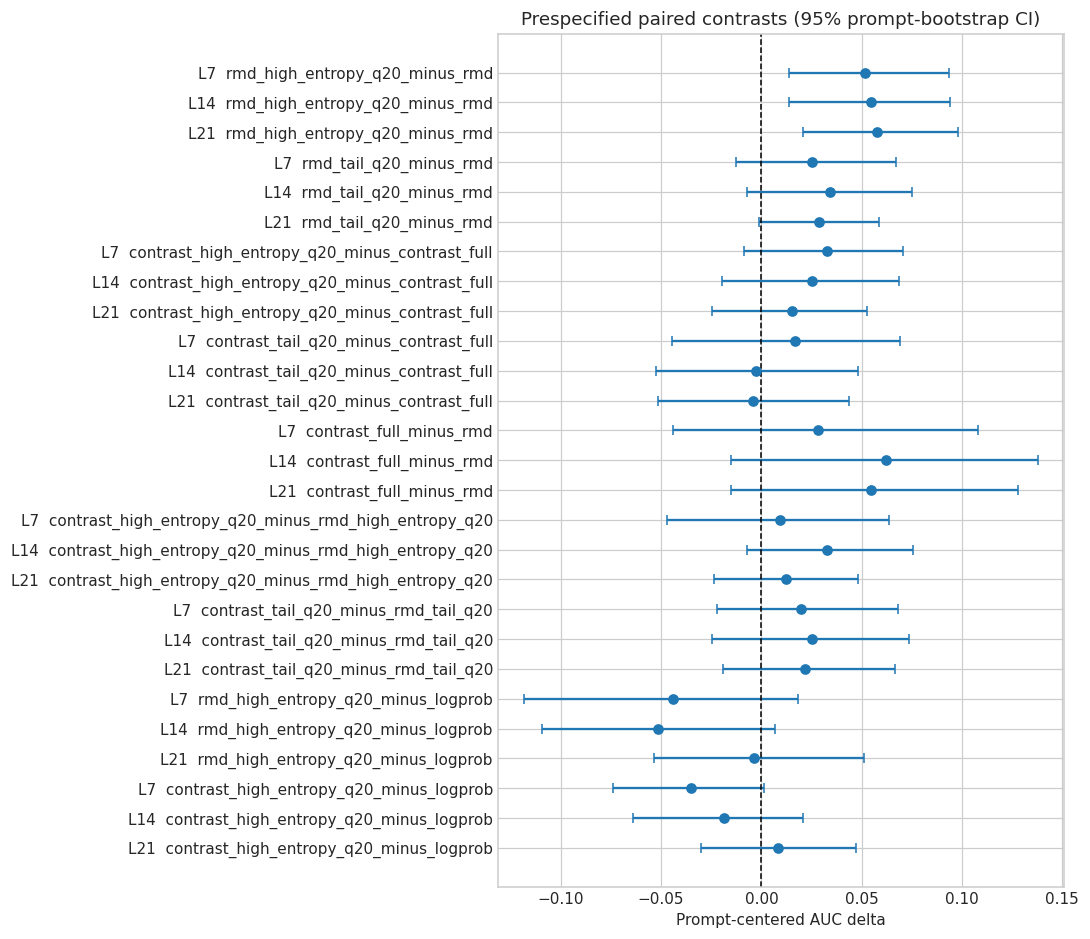

In [49]:
PRIMARY_COMPARISONS = [
    "rmd_high_entropy_q20_minus_rmd",
    "rmd_tail_q20_minus_rmd",
    "contrast_high_entropy_q20_minus_contrast_full",
    "contrast_tail_q20_minus_contrast_full",
    "contrast_full_minus_rmd",
    "contrast_high_entropy_q20_minus_rmd_high_entropy_q20",
    "contrast_tail_q20_minus_rmd_tail_q20",
    "rmd_high_entropy_q20_minus_logprob",
    "contrast_high_entropy_q20_minus_logprob",
]
forest_rows = [
    row for row in paired_rows
    if row["metric"] == "prompt_centered_auc" and row["comparison"] in PRIMARY_COMPARISONS
]
# show_rows(forest_rows, ["layer", "comparison", "point", "ci_low", "ci_high", "p", "n_valid"], limit=40)

fig, ax = plt.subplots(figsize=(10, max(4, 0.32 * len(forest_rows))))
if not forest_rows:
    note(ax, "Prespecified paired deltas not available")
else:
    ordered = sorted(forest_rows, key=lambda row: (PRIMARY_COMPARISONS.index(row["comparison"]), row["layer"]))
    y = np.arange(len(ordered))
    points = np.asarray([row["point"] for row in ordered], dtype=float)
    lows = np.asarray([row["ci_low"] for row in ordered], dtype=float)
    highs = np.asarray([row["ci_high"] for row in ordered], dtype=float)
    ax.errorbar(points, y, xerr=np.vstack([points - lows, highs - points]), fmt="o", capsize=3)
    ax.axvline(0, color="black", lw=1, ls="--")
    ax.set_yticks(y, [f"L{row['layer']}  {row['comparison']}" for row in ordered])
    ax.invert_yaxis()
    ax.set(xlabel="Prompt-centered AUC delta", title="Prespecified paired contrasts (95% prompt-bootstrap CI)")
plt.tight_layout()
plt.show()

## 6. Incremental value beyond output statistics

**The question that decides whether geometry is useful.** Sections 2–5 show
geometry roughly *ties* entropy and logprob. Tying a free baseline is only
interesting if the two are measuring different things — then combining them
beats either. If geometry is entropy in disguise, combining adds nothing.

Three cross-fitted supervised probes, all fit on training prompts:
`probe_outputs` (entropy + logprob + length), `probe_outputs + rmd_he_q20`, and
`probe_outputs + contrast_he_q20`. The first plot tests the incremental AUC; the
second shows standardized coefficients averaged over held-out folds.

**Result: weak, and one cell out of six.** `probe+rmd_he_q20 − probe` =
**+0.049 within-macro [0.006, 0.091], p=0.024 at L21 only** (centered
non-significant). One of six cells, unadjusted — it would not survive
correction.

**But the coefficients say the probe is not ignoring geometry.** At L21,
fold-averaged standardized coefficients: `rmd_he_q20` **+0.39 ± 0.11**, while
entropy **collapses from +0.28 to +0.06** once geometry enters, and length flips
negative. The probe reallocates weight *onto* geometry — it is not redundant, it
is competing for the same variance.

**The resolution is in section 7's residualization**, and it matters: label-free
projection of centered `rmd_he_q20` onto entropy+logprob+length keeps nearly all
its discrimination at L21 (residual within-macro **0.645 [0.587, 0.697]** vs
0.654 raw; R² against the output features only 0.227). Geometry is **linearly
complementary** to output uncertainty. The flat incremental probe therefore
reflects **saturation on 117 mixed prompts**, not redundancy — there is signal
to combine, but not enough held-out pairs to demonstrate the combination.

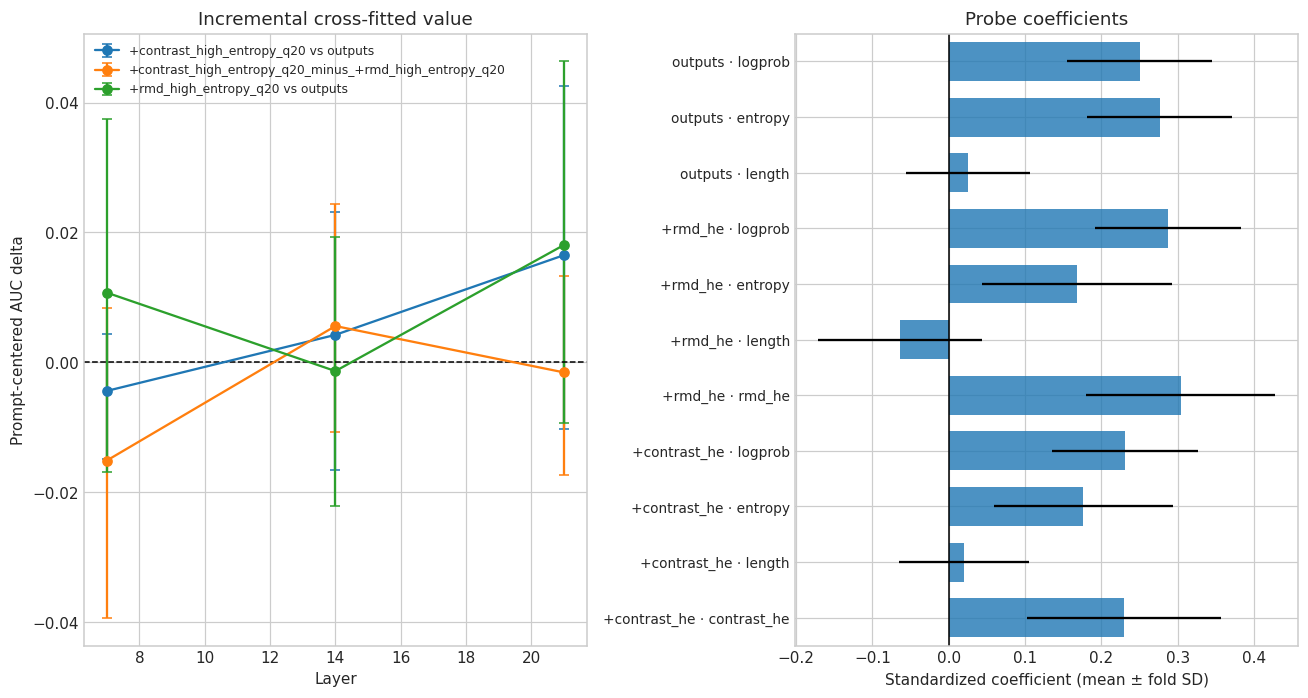

In [56]:
probe_delta_rows = [row for row in paired_rows if row["comparison"].startswith("probe_outputs_plus")]
# show_rows(probe_delta_rows, ["layer", "comparison", "metric", "point", "ci_low", "ci_high", "p"])

PRIMARY_PROBE_METHODS = [
    "probe_outputs",
    "probe_outputs_plus_rmd_high_entropy_q20",
    "probe_outputs_plus_contrast_high_entropy_q20",
]
PROBE_METHOD_LABELS = {
    "probe_outputs": "outputs",
    "probe_outputs_plus_rmd_high_entropy_q20": "+rmd_he",
    "probe_outputs_plus_contrast_high_entropy_q20": "+contrast_he",
}
FEATURE_ORDER = [
    "logprob",
    "entropy",
    "length",
    "rmd_high_entropy_q20",
    "contrast_high_entropy_q20",
]

coefficient_rows = []
for item in decomposition.get("incremental_readouts", {}).get("diagnostics", []):
    if item["method"] not in PRIMARY_PROBE_METHODS:
        continue
    for feature, value in item.get("coefficients", {}).items():
        coefficient_rows.append({
            "layer": int(item["layer"]),
            "fold": int(item["fold"]),
            "method": item["method"],
            "feature": feature,
            "coefficient": value,
        })

n_coeff = len({(row["method"], row["feature"]) for row in coefficient_rows})
fig, axes = plt.subplots(1, 2, figsize=(12, max(5.5, 0.45 * max(n_coeff, 1) + 1.5)))
metric = "prompt_centered_auc"
subset = [row for row in probe_delta_rows if row["metric"] == metric]
if not subset:
    note(axes[0], "Incremental probe deltas not available")
else:
    for comparison in sorted({row["comparison"] for row in subset}):
        rows = sorted([row for row in subset if row["comparison"] == comparison], key=lambda row: row["layer"])
        x = np.asarray([row["layer"] for row in rows])
        y = np.asarray([row["point"] for row in rows])
        low = np.asarray([row["ci_low"] for row in rows])
        high = np.asarray([row["ci_high"] for row in rows])
        axes[0].errorbar(
            x,
            y,
            yerr=np.vstack([y - low, high - y]),
            marker="o",
            capsize=3,
            label=comparison.replace("probe_outputs_plus_", "+").replace("_minus_probe_outputs", " vs outputs"),
        )
    axes[0].axhline(0, color="black", lw=1, ls="--")
    axes[0].set(xlabel="Layer", ylabel="Prompt-centered AUC delta", title="Incremental cross-fitted value")
    axes[0].legend()

if not coefficient_rows:
    note(axes[1], "Probe coefficient diagnostics not available")
else:
    grouped = defaultdict(list)
    for row in coefficient_rows:
        grouped[(row["method"], row["feature"])].append(row["coefficient"])

    def coeff_sort_key(key):
        method, feature = key
        method_rank = PRIMARY_PROBE_METHODS.index(method) if method in PRIMARY_PROBE_METHODS else 99
        feature_rank = FEATURE_ORDER.index(feature) if feature in FEATURE_ORDER else 99
        return (method_rank, feature_rank, feature)

    ordered_keys = sorted(grouped, key=coeff_sort_key)
    labels = [
        f"{PROBE_METHOD_LABELS.get(method, method)} · {feature.replace('_high_entropy_q20', '_he')}"
        for method, feature in ordered_keys
    ]
    means = [float(np.mean(grouped[key])) for key in ordered_keys]
    stds = [float(np.std(grouped[key])) for key in ordered_keys]
    y = np.arange(len(labels))
    axes[1].barh(y, means, xerr=stds, alpha=0.8, height=0.7)
    axes[1].axvline(0, color="black", lw=1)
    axes[1].set_yticks(y, labels, fontsize=9)
    axes[1].invert_yaxis()
    axes[1].set(xlabel="Standardized coefficient (mean ± fold SD)", title="Probe coefficients")
    axes[1].set_ylim(len(labels) - 0.5, -0.5)
plt.tight_layout()
plt.show()


## 7. OOF trace-level drill-down

Everything above is aggregate. This section goes to the 12,000-row OOF CSV to
check that the aggregates are not artifacts of a handful of prompts or an
outlier-driven distribution.

**Prompt-centering is the key operation.** Raw scores are dominated by
*between-prompt* variance — hard problems score badly on everything, which is a
difficulty signal, not a correctness signal (RMD's ICC is 0.94–0.97, i.e. almost
all variance is between prompts). Subtracting each prompt's mean removes the
difficulty component and leaves the within-prompt question this notebook is
about. Compare parseable correct vs incorrect traces *after* centering.

**Note `FOCUS_LAYER = 14` in the setup cell.** L14 is a reasonable default for
browsing, but **L21 is the prespecified layer** that carries every claim above.
Set `FOCUS_LAYER = 21` to inspect the cells that the confirmatory tests actually
used.

This is also where the label-free **residualization** referenced in section 6
lives — regressing centered geometry on centered entropy/logprob/length and
re-scoring the residual. It uses no labels, so it cannot leak, and it is the
cleanest available answer to "is this just entropy?". It is exploratory: it was
not prespecified and carries no adjusted interval.

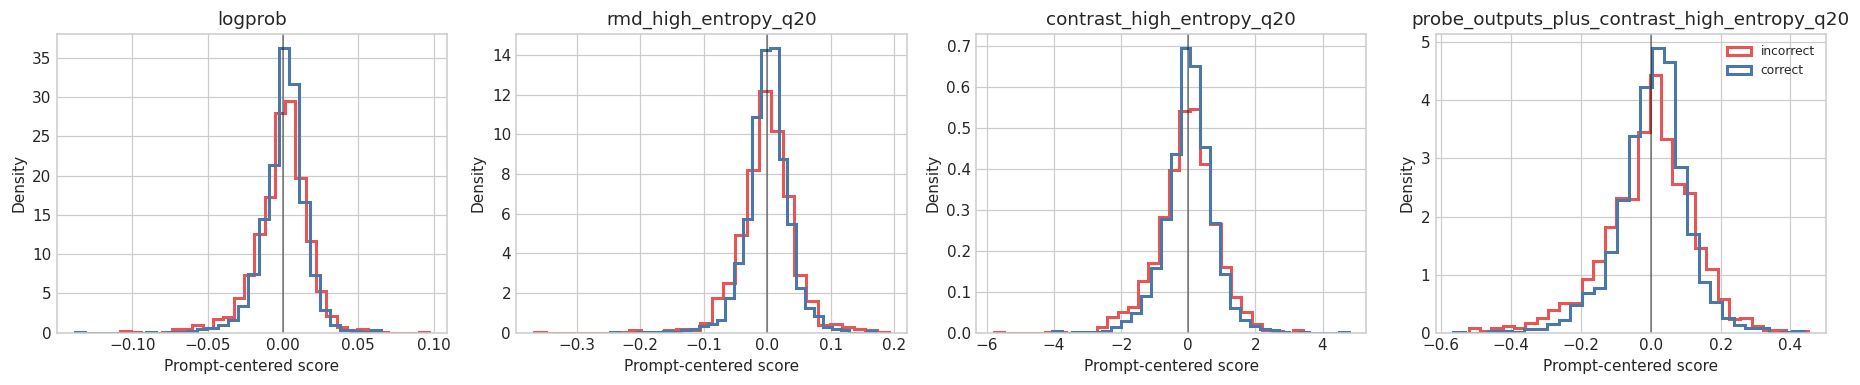

| prompt_id | sample_id | is_correct | predicted_answer | trace_length | logprob_centered | rmd_high_entropy_q20_centered | contrast_high_entropy_q20_centered | probe_outputs_plus_contrast_high_entropy_q20_centered |
|---|---|---|---|---|---|---|---|---|
| 0 | 0 | 0 | \left(3,\frac{\pi | 380 | 0.0257 | 0.0213 | 0.2791 | 0.1205 |
| 0 | 1 | 0 | \left(3,\frac{\pi | 334 | 0.0169 | 0.0054 | 0.0500 | 0.0768 |
| 0 | 2 | 0 | (3,\frac{\pi | 331 | -0.0214 | -0.0454 | -1.1169 | -0.1721 |
| 0 | 3 | 0 | (3,\frac{\pi | 357 | 0.0068 | -0.0076 | 0.0879 | 0.0359 |
| 0 | 4 | 0 | (3,\frac{\pi | 357 | 0.0120 | 0.0244 | 0.7515 | 0.1143 |
| 0 | 5 | 0 | (3,\frac{\pi | 350 | 0.0020 | 0.0189 | 0.7124 | 0.0658 |
| 0 | 6 | 0 | (3,\frac{\pi | 370 | -0.0340 | -0.0559 | -1.4718 | -0.2718 |
| 0 | 7 | 0 | (3,\frac{\pi | 351 | -0.0080 | 0.0390 | 0.7078 | 0.0305 |
| 1 | 0 | 1 | p-q | 615 | -0.0016 | 0.0027 | -0.1531 | -0.0367 |
| 1 | 1 | 1 | p-q | 545 | -0.0030 | -0.0311 | -0.7066 | -0.0548 |
| 1 | 2 | 1 | p-q | 704 | 0.0050 | 0.0615 | 1.1281 | 0.1325 |
| 1 | 3 | 1 | p-q | 623 | 0.0038 | -0.0015 | 0.3492 | 0.0282 |

_Showing 12 of 3672 rows._

In [42]:
parseable_oof = [
    row for row in oof_rows
    if row.get("predicted_answer") not in (None, "") and int(row["layer"]) == FOCUS_LAYER
]


def add_prompt_centered_scores(rows: list[dict], methods: list[str]) -> list[dict]:
    copied = [dict(row) for row in rows]
    by_prompt = defaultdict(list)
    for row in copied:
        by_prompt[int(row["prompt_id"])].append(row)
    for group in by_prompt.values():
        for method in methods:
            key = f"{method}_score"
            values = [row.get(key) for row in group]
            if all(value is not None for value in values):
                mean = float(np.mean(values))
                for row, value in zip(group, values):
                    row[f"{method}_centered"] = float(value) - mean
    return copied


centered_oof = add_prompt_centered_scores(parseable_oof, FOCUS_METHODS)
available_focus = [
    method for method in FOCUS_METHODS
    if centered_oof and all(f"{method}_centered" in row for row in centered_oof)
]

fig, axes = plt.subplots(1, max(1, len(available_focus)), figsize=(4.2 * max(1, len(available_focus)), 3.6))
axes = np.atleast_1d(axes)
if not available_focus:
    note(axes[0], "OOF CSV or requested score columns not available")
else:
    for ax, method in zip(axes, available_focus):
        for label, color in ((0, "#E45756"), (1, "#4C78A8")):
            values = [row[f"{method}_centered"] for row in centered_oof if int(row["is_correct"]) == label]
            ax.hist(values, bins=30, density=True, histtype="step", lw=2, color=color, label="correct" if label else "incorrect")
        ax.axvline(0, color="black", lw=1, alpha=0.5)
        ax.set(title=method, xlabel="Prompt-centered score", ylabel="Density")
    axes[-1].legend()
plt.tight_layout()
plt.show()

show_rows(centered_oof, ["prompt_id", "sample_id", "is_correct", "predicted_answer", "trace_length", *[f"{method}_centered" for method in available_focus]], limit=12)

## 8. Answer selection and geometry-only tie-breakers

**The application test: can geometry pick the right answer out of 8 samples?**

Design point that governs everything here: tie-breakers are constrained to
clusters **tied for the largest answer count**. They cannot overturn a strict
majority — by construction, not by weakness. This is deliberate (overturning
majorities is a much stronger and much riskier intervention), but it caps the
achievable effect before any scoring happens.

**Result: negative.** Majority vote **0.596** Pass@1, against random 0.557 and
oracle Pass@8 0.676. Every geometry and logprob tie-break variant lands within
**±0.006** of majority. Weighted RMD voting, which *is* allowed to overturn
majorities, does **worse** (0.582–0.584) — and every top-1 selector is ≤ 0.582.

Compare the tie-breakers against majority vote, the mean-log-probability
tie-breaker, and the trace-level selectors. The pattern is flat across all of
them, which is itself informative: this is not "geometry is a bad selector", it
is "at N=8 there is almost nothing for any selector to do". Section 9 measures
exactly how little.

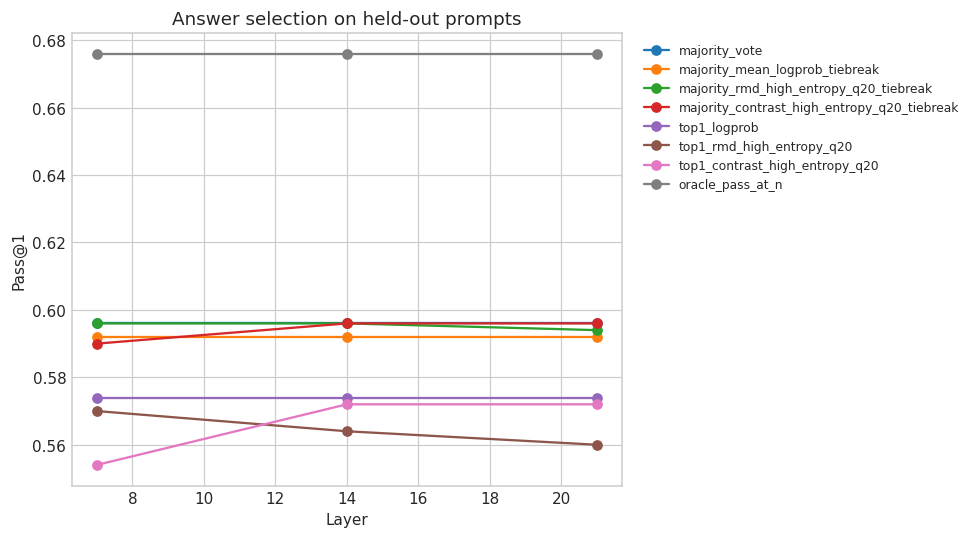

In [57]:
def flatten_selectors(result: dict) -> list[dict]:
    rows = []
    for layer, payload in result.get("layers", {}).items():
        for name, values in payload.get("selectors", {}).items():
            ci = values.get("confidence_interval", {})
            pass_at_1 = values.get("pass_at_1", values.get("pass_at_1_mean"))
            rows.append({
                "layer": int(layer),
                "selector": name,
                "pass_at_1": pass_at_1,
                "ci_low": ci.get("ci_low"),
                "ci_high": ci.get("ci_high"),
                "n_prompts": values.get("n_prompts", values.get("n_problems")),
            })
    return rows


selector_rows = flatten_selectors(selection)
IMPORTANT_SELECTORS = [
    "majority_vote",
    "majority_mean_logprob_tiebreak",
    "majority_rmd_high_entropy_q20_tiebreak",
    "majority_contrast_high_entropy_q20_tiebreak",
    "top1_logprob",
    "top1_rmd_high_entropy_q20",
    "top1_contrast_high_entropy_q20",
    "oracle_pass_at_n",
]
important_selector_rows = [row for row in selector_rows if row["selector"] in IMPORTANT_SELECTORS]
# show_rows(important_selector_rows)

fig, ax = plt.subplots(figsize=(9, 5))
if not important_selector_rows:
    note(ax, "Selection results not available")
else:
    for selector_name in IMPORTANT_SELECTORS:
        rows = sorted([row for row in important_selector_rows if row["selector"] == selector_name], key=lambda row: row["layer"])
        if rows:
            ax.plot([row["layer"] for row in rows], [row["pass_at_1"] for row in rows], marker="o", label=selector_name)
    ax.set(xlabel="Layer", ylabel="Pass@1", title="Answer selection on held-out prompts")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 9. Paired tie-breaker deltas

**Why the section-8 null is structural, not a power failure.**

A tie-breaker only changes the answer on prompts that actually have a tie. The
win/loss decomposition isolates that set, and it is tiny: **only 39 of 500
prompts have a tied top answer at N=8, and only ~10 of those ties contain both a
correct and an incorrect option.** Everything else is a strict majority the
tie-breaker is forbidden to touch.

That puts a **hard ceiling of roughly 2 Pass@1 points** on any tie-breaker,
perfect or otherwise. The observed spread (±0.006, 15/15 paired deltas
p ≥ 0.248) sits comfortably inside it. A large tie count in the table is
expected and is not evidence of anything.

**So this result closes the question rather than deferring it.** The honest
conclusion is not "geometry needs a better selector" but "N=8 majority-vote
tie-breaking is the wrong application" — there is no headroom to compete for.
Testing selection properly would need larger N, or permission to overturn
majorities (which weighted voting had, and lost with). See
`EXPERIMENT_LOG.md` (2026-07-25) for why the whole Best-of-N branch was retired
on this basis, and notebook 12's E7 for the matching power audit.

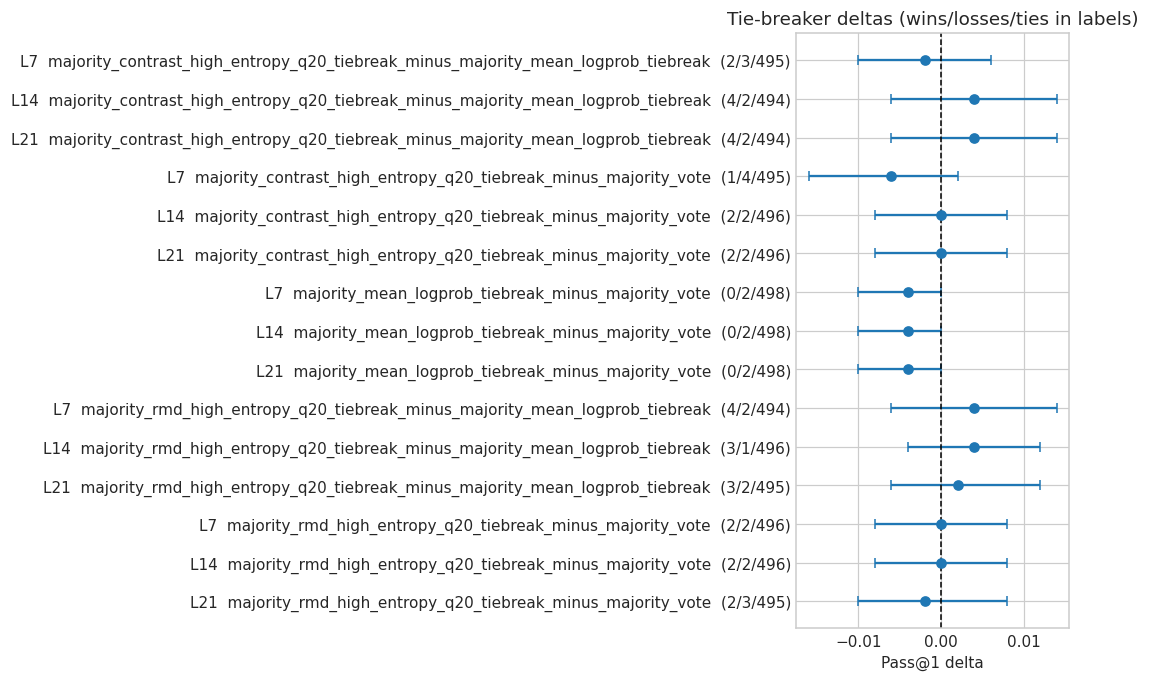

In [58]:
selector_delta_rows = []
for layer, payload in selection.get("layers", {}).items():
    for comparison, values in payload.get("paired_selector_deltas", {}).items():
        selector_delta_rows.append({"layer": int(layer), "comparison": comparison, **values})

# show_rows(selector_delta_rows, ["layer", "comparison", "point_estimate", "ci_low", "ci_high", "p_two_sided", "wins", "losses", "ties"])

fig, ax = plt.subplots(figsize=(10, max(4, 0.42 * len(selector_delta_rows))))
if not selector_delta_rows:
    note(ax, "Paired selector deltas not available; rerun the selection DVC stage after decomposition")
else:
    ordered = sorted(selector_delta_rows, key=lambda row: (row["comparison"], row["layer"]))
    y = np.arange(len(ordered))
    points = np.asarray([row["point_estimate"] for row in ordered], dtype=float)
    lows = np.asarray([row["ci_low"] for row in ordered], dtype=float)
    highs = np.asarray([row["ci_high"] for row in ordered], dtype=float)
    ax.errorbar(points, y, xerr=np.vstack([points - lows, highs - points]), fmt="o", capsize=3)
    ax.axvline(0, color="black", lw=1, ls="--")
    ax.set_yticks(y, [f"L{row['layer']}  {row['comparison']}  ({row['wins']}/{row['losses']}/{row['ties']})" for row in ordered])
    ax.invert_yaxis()
    ax.set(xlabel="Pass@1 delta", title="Tie-breaker deltas (wins/losses/ties in labels)")
plt.tight_layout()
plt.show()

## 10. Investigation scratchpad

Free-form exploration. Nothing here is confirmatory — new comparisons invented
at this point are, by definition, not prespecified, and should be reported as
exploratory or promoted into `prompt_decomposition.py` and re-run.

Variables intentionally left in memory:

- `decomposition`, `selection` — raw JSON objects
- `oof_rows`, `centered_oof` — trace-level dictionaries (raw and prompt-centered)
- `factorial_rows`, `paired_rows`, `alignment_rows` — tidied section 2/4/5 tables
- `coefficient_rows`, `selector_rows`, `selector_delta_rows` — section 6/8/9 tables

The cell below shows all 8 traces for a single prompt sorted by any score — the
fastest way to build intuition for what a "geometrically distant" trace actually
looks like, and to sanity-check whether a score is tracking reasoning quality or
just length and termination.

In [45]:
PROMPT_ID = 0
SORT_METHOD = "contrast_high_entropy_q20"

prompt_rows = [
    row for row in oof_rows
    if int(row["layer"]) == FOCUS_LAYER and int(row["prompt_id"]) == PROMPT_ID
]
sort_key = f"{SORT_METHOD}_score"
if prompt_rows and all(row.get(sort_key) is not None for row in prompt_rows):
    prompt_rows = sorted(prompt_rows, key=lambda row: row[sort_key], reverse=True)

show_rows(
    prompt_rows,
    [
        "sample_id", "is_correct", "predicted_answer", "gold_answer", "trace_length",
        "logprob_score", "rmd_score", "rmd_high_entropy_q20_score",
        "contrast_high_entropy_q20_score", sort_key,
    ],
)

| sample_id | is_correct | predicted_answer | gold_answer | trace_length | logprob_score | rmd_score | rmd_high_entropy_q20_score | contrast_high_entropy_q20_score | contrast_high_entropy_q20_score |
|---|---|---|---|---|---|---|---|---|---|
| 4 | 0 | (3,\frac{\pi | \left(3,\frac{\pi}{2}\right) | 357 | -0.0645 | 0.1067 | 0.2673 | 3.6945 | 3.6945 |
| 5 | 0 | (3,\frac{\pi | \left(3,\frac{\pi}{2}\right) | 350 | -0.0745 | 0.1208 | 0.2618 | 3.6553 | 3.6553 |
| 7 | 0 | (3,\frac{\pi | \left(3,\frac{\pi}{2}\right) | 351 | -0.0845 | 0.1067 | 0.2819 | 3.6507 | 3.6507 |
| 0 | 0 | \left(3,\frac{\pi | \left(3,\frac{\pi}{2}\right) | 380 | -0.0508 | 0.1098 | 0.2642 | 3.2221 | 3.2221 |
| 3 | 0 | (3,\frac{\pi | \left(3,\frac{\pi}{2}\right) | 357 | -0.0697 | 0.1067 | 0.2353 | 3.0308 | 3.0308 |
| 1 | 0 | \left(3,\frac{\pi | \left(3,\frac{\pi}{2}\right) | 334 | -0.0596 | 0.1186 | 0.2483 | 2.9929 | 2.9929 |
| 2 | 0 | (3,\frac{\pi | \left(3,\frac{\pi}{2}\right) | 331 | -0.0979 | 0.1232 | 0.1975 | 1.8261 | 1.8261 |
| 6 | 0 | (3,\frac{\pi | \left(3,\frac{\pi}{2}\right) | 370 | -0.1106 | 0.1203 | 0.1870 | 1.4712 | 1.4712 |

## Questions worth pursuing

The original checklist, with what this run answered:

| Question | Answer |
|:---|:---|
| Do high-entropy gains replicate at all three preregistered layers, or only one? | **All three.** +0.052/+0.055/+0.058, p ≤ 0.006, growing with depth. |
| Does contrast beat region-matched RMD, rather than only full-trace RMD? | **No** (p ≥ 0.118). The apparent supervision gain was a region-choice gain. |
| Is high-entropy better than the deterministic random-20% control? | **Yes.** +0.049/+0.058/+0.057, p ≤ 0.014. The localization is entropy-specific. |
| Does direction alignment clear the shuffled null consistently across folds? | **Yes, 5/5 folds at L21** (p ≤ 0.004) — but pairwise cosine is only 0.016–0.029, and at L21 the random-region control clears it too, so the alignment is not localized. |
| Does output+contrast improve over output-only, and over output+RMD? | **No.** Only output+RMD at L21 reaches p<0.05 (1 of 6 cells, unadjusted). |
| Are selector changes concentrated in parse failures or genuine competing answers? | **Neither — there are almost no changes to attribute.** Only ~10 of 500 prompts have a tie with correctness headroom. |
| Are any conclusions driven by a handful of prompts? | **Structurally, yes**: every within-prompt number rests on 117 mixed prompts. This is the main threat to the section 2–6 results and the reason cross-model confirmation is the next stage. |

**Still open:**

- **Cross-model replication.** Does localization + entropy-specificity hold at
  each model's prespecified deepest layer on DeepSeek and DeepSeek-Llama? This
  is the registered gate — if it fails on DeepSeek at L21, the localization
  claim demotes to Qwen-specific.
- **What do the high-entropy 20% tokens actually *are*?** No token-level audit
  has been done. Are they arithmetic steps, hedges, discourse pivots? This is
  the difference between a statistical finding and a mechanistic one.
- **Entropy-residualized geometry as a registered contrast**, rather than the
  exploratory version in section 7.

Record observations in new markdown cells next to the relevant plot; keep
confirmatory claims tied to the prespecified paired intervals rather than
whichever layer looks best.